# Linear Regression: Predicting Salary from Experience

This project demonstrates a simple linear regression model using Python and Scikit-learn.

## Objective
The goal is to predict employee salary based on years of experience using linear regression.

## Dataset Information
The dataset contains two columns:

- `exp(in months)` → Employee work experience in months
- `salary(in thousands)` → Salary in thousands

## Technologies Used

- **Python** → Main programming language used for data analysis and machine learning.

- **Pandas (`pd`)** → Used for loading, cleaning, and working with structured data in DataFrames.

- **NumPy (`np`)** → Used for numerical operations and handling arrays efficiently.

- **Matplotlib (`plt`)** → Used for data visualisation and plotting the regression graph.

- **Scikit-learn (`sklearn`)** → Machine learning library used for:
  - splitting training and testing data
  - building the Linear Regression model
  - evaluating model performance

### Specific Modules Used

- `train_test_split` → Splits the dataset into training and testing sets.

- `linear_model.LinearRegression()` → Creates and trains the linear regression model.

- `mean_absolute_error (MAE)` → Measures the average prediction error.

- `mean_squared_error (MSE)` → Measures squared prediction error to penalise larger mistakes.

- `r2_score` → Shows how well the model explains the data.

- `mean_absolute_percentage_error (MAPE)` → Measures prediction error in percentage form.

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn import linear_model as lm
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error

In [39]:
df = pd.read_csv('SalaryData.csv')
df.head()

,exp(in months),salary(in thousands)
0,18.290293,16.521825
1,17.023407,11.666234
2,26.343613,23.167255
3,19.105834,20.877145
4,27.742516,23.166236


In [40]:
X = df[['exp(in months)']]
y = df['salary(in thousands)']

## Defining Input and Output Variables

In machine learning:

- **X (Input / Independent Variable)** → The feature used to make predictions.
- **y (Output / Dependent Variable)** → The value we want to predict.

For this project:

- `exp(in months)` is the input feature (`X`)
- `salary(in thousands)` is the target variable (`y`)

The model learns the relationship between employee experience and salary.

---

## Understanding Linear Regression

Linear Regression is a supervised machine learning algorithm used to predict continuous numerical values.

It works by finding the **best fit straight line** through the data points.

The mathematical equation is:

y = mx + c

Where:

- `y` → Predicted output (Salary)
- `x` → Input feature (Experience)
- `m` → Slope of the line (how much salary changes with experience)
- `c` → Intercept (starting value when experience is 0)

The goal of linear regression is to minimise prediction error and create a line that best represents the relationship between input and output data.

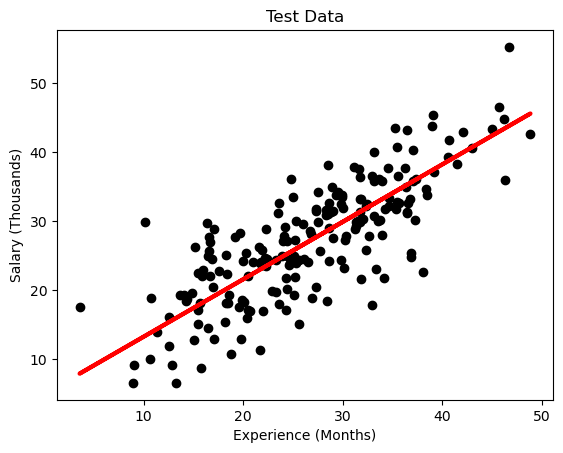

In [41]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

plt.scatter(X_test, y_test, color='black')
plt.title('Test Data')
plt.xlabel('Experience (Months)')
plt.ylabel('Salary (Thousands)')

lr = lm.LinearRegression()
lr.fit(X_train,y_train)
y_pred = lr.predict(X_test)

plt.plot(X_test, y_pred, linewidth=3, color='red')


## When to Use Each Metric

### MAE (Mean Absolute Error)
Use when:
- you want a simple and easy-to-understand error measure
- all errors should be treated equally

Best for:
- business interpretation
- understanding average prediction error directly

Example:
> “The model prediction is off by an average of 3 salary units.”

---

### MSE (Mean Squared Error)
Use when:
- large errors should be penalised more heavily
- reducing major prediction mistakes is important

Best for:
- machine learning optimisation
- identifying models with large prediction errors

Example:
A prediction error of 20 is penalised much more than an error of 2 because errors are squared.

---

### R² Score
Use when:
- you want to understand how well the model explains the dataset
- comparing regression model performance

Best for:
- measuring overall model fit
- model comparison

Example:
> R² = 0.92 means the model explains 92% of salary variation using experience.

---

### MAPE (Mean Absolute Percentage Error)
Use when:
- percentage-based error is easier to understand
- comparing performance across datasets with different scales

Best for:
- finance
- sales forecasting
- business reporting

Example:
> “The model predictions are off by 8% on average.”

In [42]:
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred)) 
print(f"MAPE: {mean_absolute_percentage_error(y_test, y_pred) * 100 :.2f} %")

MAE: 4.1621356133144705
MSE: 27.650268732842278
R2 Score: 0.6208258933084713
MAPE: 18.82 %
